<a href="https://colab.research.google.com/github/Yashzope/EDA_PracT/blob/main/eda_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
from scipy.stats import chi2
from scipy.stats import f
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import probplot
import xgboost as xgb
import os
os.chdir('/content/drive/MyDrive/AAS_data')

In [5]:
# loading all 9 datasets used in this project
df1 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/merged_analysis.csv")
df2 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/ticker_statistics.csv")
df3 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/balance_sheet.csv")
df4 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/financial_ratios.csv")
df5 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/quarterly_results.csv")
df6 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/cash_flow.csv")
df7 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/historical_data.csv")
df8 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/company_overview.csv")
df9 = pd.read_csv("/content/drive/MyDrive/AAS_data/sm/nse_tickers.csv")

In [6]:
# missing values per column for each dataset
# any column with nulls needs to be handled before modelling
for name, d in [('merged_analysis',df1),('ticker_statistics',df2),('balance_sheet',df3),
                ('financial_ratios',df4),('quarterly_results',df5),('cash_flow',df6),
                ('historical_data',df7),('company_overview',df8),('nse_tickers',df9)]:
    missing = d.isnull().sum()
    if missing.any():
        print(f"\n{name}:")
        print(missing[missing > 0])


merged_analysis:
gross_margin_pct             31
operating_margin_pct         15
net_profit_margin_pct         5
ebitda_margin_pct            15
roe_pct                      11
roa_pct                      10
roce_pct                     21
current_ratio                23
quick_ratio                 184
cash_ratio                   23
debt_to_equity               46
debt_to_assets               45
interest_coverage            81
equity_multiplier            11
asset_turnover               10
inventory_turnover          204
receivables_turnover       1412
payables_turnover            59
days_inventory              214
days_receivables           1412
days_payables                70
cash_conversion_cycle      1414
operating_cf_to_revenue    1407
fcf_to_revenue             1407
capex_to_revenue           1409
fcf_to_net_income          1407
eps_basic                     3
eps_diluted                   3
pe_ratio                    170
forward_pe                  888
pb_ratio              

 Company Overview EDA

In [7]:
# how many companies exist per sector in the full dataset
df8['sector'].value_counts()

,count
sector,
Industrials,323
Consumer Cyclical,302
Basic Materials,273
Technology,119
Financial Services,110
Consumer Defensive,103
Healthcare,95
Real Estate,65
Communication Services,46


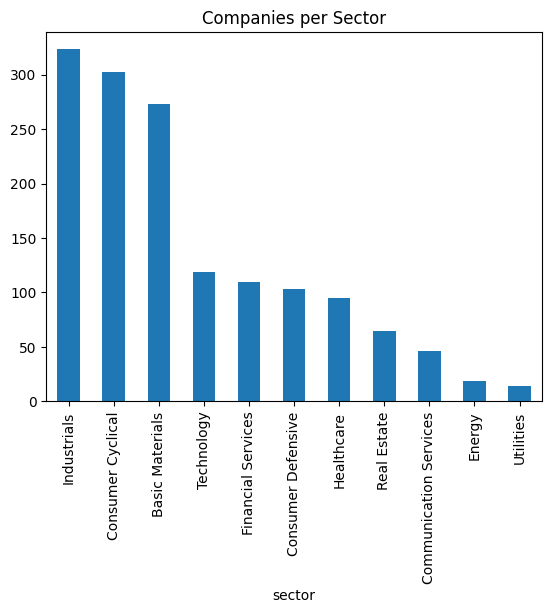

In [8]:
# bar chart — visual count of companies per sector
df8['sector'].value_counts().plot(kind='bar')
plt.title('Companies per Sector')
plt.show()

In [9]:
# all company names with their sector
df8[['company_name','sector']]

,company_name,sector
0,20 Microns Limited,Basic Materials
1,3i Infotech Limited,Technology
2,5paisa Capital Limited,Financial Services
3,63 moons technologies limited,Technology
4,A2Z Infra Engineering Limited,Industrials
...,...,...
1467,ZIM Laboratories Limited,Healthcare
1468,Zodiac Clothing Company Limited,Consumer Cyclical
1469,Zota Health Care Limited,Healthcare
1470,Zuari Agro Chemicals Limited,Basic Materials


In [10]:
# filter by sector to see companies in each industry
df8[df8['sector']=='Technology']

,symbol,company_name,sector,industry,market_cap_crore,52w_high,52w_low,current_price,avg_volume,beta,dividend_yield,pe_ratio,forward_pe,pb_ratio,ev_ebitda,ev_revenue,profit_margin,operating_margin,roe,roa,revenue_growth,earnings_growth,book_value,promoter_holding,institutional_holding
1,3IINFOLTD,3i Infotech Limited,Technology,Information Technology Services,357.56,26.45,12.68,17.24,520047,-0.180,NaN,9.472527,NaN,0.967072,-19.578,0.508,0.05114,-0.08226,0.10256,-0.03820,-0.060,NaN,17.827,0.13386,0.00225
3,63MOONS,63 moons technologies limited,Technology,Software - Application,3121.13,1130.00,467.00,677.35,215161,0.722,0.18,NaN,NaN,0.879177,-4.515,6.010,-0.10602,-0.63594,-0.01520,-0.05193,5.195,1.043,770.436,0.58128,0.00491
5,AAATECH,AAA Technologies Limited,Technology,Information Technology Services,120.66,136.00,76.11,94.07,23732,0.314,1.58,58.428570,NaN,3.930392,69.894,5.686,0.10123,-0.30162,0.06677,0.02562,-0.681,NaN,23.934,0.75840,0.00000
16,ACCELYA,Accelya Solutions India Limited,Technology,Information Technology Services,1648.75,1527.00,1012.40,1104.60,10404,0.424,8.11,15.309771,17.645367,6.272608,11.835,3.027,0.18417,0.14573,NaN,NaN,-0.005,-0.293,176.099,0.75130,0.00210
21,ADSL,Allied Digital Services Limited,Technology,Information Technology Services,727.58,209.53,86.27,128.62,351440,0.628,2.51,20.579199,10.372581,1.187802,12.789,0.743,0.02977,-0.05673,0.05392,0.02286,0.310,NaN,108.284,0.55588,0.00150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1439,WEBELSOLAR,Websol Energy System Limited,Technology,Solar,4428.03,157.30,50.40,101.99,5811101,0.248,NaN,14.611748,NaN,11.003345,10.797,4.409,0.28873,0.30507,0.66685,0.31733,1.321,1.443,9.269,0.34827,0.02912
1455,XCHANGING,Xchanging Solutions Limited,Technology,Information Technology Services,706.08,103.00,47.50,63.38,117063,0.577,3.14,11.868914,NaN,1.923812,6.820,2.303,0.29297,0.37173,0.15754,0.08338,0.011,0.106,32.945,0.75000,0.00001
1456,XELPMOC,Xelpmoc Design and Tech Limited,Technology,Information Technology Services,123.90,155.50,79.01,83.72,29894,0.778,NaN,NaN,NaN,1.606108,-16.763,31.925,-2.03269,-1.86922,-0.10935,-0.06442,0.528,NaN,52.126,0.61694,0.00000
1458,XTGLOBAL,XTGlobal Infotech Limited,Technology,Software - Application,432.15,46.25,25.20,32.22,54922,0.798,0.33,38.357147,NaN,2.960581,23.127,1.662,0.03965,0.03129,0.07300,0.04670,0.028,0.933,10.883,0.87698,0.00001


In [11]:
df8[df8['sector']=='Financial Services']

,symbol,company_name,sector,industry,market_cap_crore,52w_high,52w_low,current_price,avg_volume,beta,dividend_yield,pe_ratio,forward_pe,pb_ratio,ev_ebitda,ev_revenue,profit_margin,operating_margin,roe,roa,revenue_growth,earnings_growth,book_value,promoter_holding,institutional_holding
2,5PAISA,5paisa Capital Limited,Financial Services,Capital Markets,1645.46,432.50,245.50,351.00,58204,0.538,NaN,24.858356,22.64516,1.691297,NaN,0.052,0.153760,0.19001,0.07054,0.02473,0.064,0.079,207.533,0.71242,0.12340
32,AFIL,AKME FINTRADE (INDIA) LTD,Financial Services,Credit Services,611.21,11.10,3.92,10.53,1520157,NaN,NaN,10.636363,NaN,1.051423,NaN,10.150,0.505410,0.56567,0.10501,0.05258,0.466,0.642,10.015,0.51498,0.01953
33,AFSL,Abans Financial Services Limited,Financial Services,Capital Markets,1022.54,267.59,194.41,201.13,29921,-0.091,NaN,9.679018,NaN,0.815133,-0.293,-0.002,0.004030,0.00182,0.08358,0.03395,7.189,NaN,246.745,0.81980,0.06888
51,ALGOQUANT,Algoquant Fintech Limited,Financial Services,Capital Markets,1638.51,71.01,47.80,58.29,1315922,0.393,NaN,48.983192,NaN,12.136166,27.082,6.072,0.141820,0.26845,0.28374,0.12364,NaN,26.726,4.803,0.78523,0.00000
57,ALMONDZ,Almondz Global Securities Limited,Financial Services,Capital Markets,227.54,26.60,10.68,13.01,132307,0.349,NaN,7.981595,NaN,0.863190,NaN,1.569,0.148190,0.01606,0.10742,0.07821,0.067,-0.222,15.072,0.66435,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1379,UYFINCORP,U. Y. Fincorp Limited,Financial Services,Credit Services,268.81,23.30,11.16,14.13,88511,0.110,NaN,5.562992,NaN,0.690515,3.903,1.658,0.296380,0.35417,0.13437,0.10944,3.549,14.332,20.463,0.73665,0.00000
1400,VHL,Vardhman Holdings Limited,Financial Services,Credit Services,1153.55,4275.00,2870.00,3614.40,760,-0.135,0.16,5.341293,NaN,0.308814,74.445,64.393,14.548559,0.91814,NaN,NaN,-0.114,-0.183,11704.126,0.85521,0.00006
1423,VLSFINANCE,VLS Finance Limited,Financial Services,Capital Markets,772.95,339.00,198.81,246.33,13913,0.202,0.62,37.955320,NaN,0.389804,NaN,15.027,0.453790,1.06593,0.00949,0.00885,NaN,NaN,631.933,0.66628,0.00180
1438,WEALTH,Wealth First Portfolio Managers Limited,Financial Services,Capital Markets,1074.72,1387.95,774.95,1008.65,4009,-0.248,1.60,27.817156,NaN,7.141846,NaN,15.279,0.544130,0.73826,0.25640,0.24220,NaN,NaN,141.231,0.77559,0.00043


In [12]:
df8[df8['sector']=='Healthcare']

,symbol,company_name,sector,industry,market_cap_crore,52w_high,52w_low,current_price,avg_volume,beta,dividend_yield,pe_ratio,forward_pe,pb_ratio,ev_ebitda,ev_revenue,profit_margin,operating_margin,roe,roa,revenue_growth,earnings_growth,book_value,promoter_holding,institutional_holding
6,AAREYDRUGS,Aarey Drugs & Pharmaceuticals Limited,Healthcare,Drug Manufacturers - Specialty & Generic,257.32,100.000,50.310,90.75,123661,1.144,NaN,65.287770,NaN,1.716637,44.085,0.669,0.00840,0.01844,0.02747,0.00918,0.753,2.516,52.865,0.55330,0.01055
9,AARTIDRUGS,Aarti Drugs Limited,Healthcare,Drug Manufacturers - Specialty & Generic,3399.35,564.050,318.950,372.45,153761,0.355,0.53,17.444965,14.107955,2.193618,12.761,1.550,0.07598,0.10901,0.13359,0.05673,0.064,-0.120,169.788,0.60163,0.11116
10,AARTIPHARM,Aarti Pharmalabs Limited,Healthcare,Drug Manufacturers - Specialty & Generic,6437.15,971.000,585.000,710.05,248205,0.231,0.56,36.866560,27.845098,3.030840,17.963,3.973,0.09602,0.17500,0.08492,0.05833,0.033,-0.308,234.275,0.44544,0.12538
37,AHCL,ANLON HEALTHCARE LIMITED,Healthcare,Drug Manufacturers - Specialty & Generic,857.33,17.275,9.078,16.13,5520283,NaN,NaN,26.442621,NaN,3.156555,16.571,4.579,0.16581,0.29475,0.17355,0.10354,0.040,-0.548,5.110,0.84672,0.00000
47,AKUMS,AKUMS DRUGS AND PHARMA L,Healthcare,Drug Manufacturers - Specialty & Generic,9394.34,639.000,409.300,613.60,294007,NaN,0.16,36.830730,19.506723,2.835306,15.686,1.836,0.05851,0.09842,0.08019,0.04838,0.096,-0.426,216.414,0.80174,0.13382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,WANBURY,Wanbury Limited,Healthcare,Drug Manufacturers - Specialty & Generic,975.16,315.200,161.500,279.10,85788,NaN,NaN,14.371782,NaN,15.430973,NaN,NaN,-0.25901,0.05492,NaN,NaN,-0.192,NaN,18.087,0.51185,0.02071
1448,WINDLAS,Windlas Biotech Limited,Healthcare,Drug Manufacturers - Specialty & Generic,1782.56,1097.900,697.400,863.80,54886,0.274,0.68,27.730337,NaN,3.394906,15.001,1.738,0.07351,0.07248,0.12232,0.05546,0.177,-0.026,254.440,0.67305,0.08023
1460,YATHARTH,Yatharth Hospital & Trauma Care Services Limited,Healthcare,Medical Care Facilities,8257.57,889.900,514.500,857.00,461838,0.989,NaN,47.139713,27.013395,4.890045,25.959,6.693,0.14224,0.14614,0.09889,0.07168,0.442,0.129,175.254,0.56938,0.12041
1467,ZIMLAB,ZIM Laboratories Limited,Healthcare,Drug Manufacturers - Specialty & Generic,684.73,129.300,59.310,127.87,100951,0.818,NaN,107.453780,NaN,2.400233,29.709,1.971,0.01559,0.02239,0.02129,0.01273,-0.032,-0.249,53.274,0.71352,0.00000


In [13]:
# top 20 companies by market cap — tells us who the biggest players are
df8.sort_values('market_cap_crore', ascending=False)[['company_name','sector','market_cap_crore']].head(20)

,company_name,sector,market_cap_crore
758,Vedant Fashions Limited,Consumer Cyclical,9996.08
631,Jubilant Ingrevia Limited,Basic Materials,9966.11
998,QUALITY POWER ELEC EQUP L,Industrials,9911.30
846,NCC Limited,Industrials,9892.98
263,Cyient Limited,Industrials,9877.29
994,PVR INOX Limited,Communication Services,9717.87
423,Genus Power Infrastructures Limited,Industrials,9651.91
1255,SUDEEP PHARMA LIMITED,Healthcare,9611.36
945,Pearl Global Industries Limited,Consumer Cyclical,9610.91
146,Banco Products (India) Limited,Consumer Cyclical,9510.55


Filter to 5 Stocks & Basic EDA

In [14]:
# we pick one stock from each sector for a balanced cross-sector analysis
df10 = ['SONATSOFTW','REPCOHOME','THYROCARE','JAMNAAUTO','JKLAKSHMI']

df = pd.read_csv('historical_data.csv')
df['date'] = pd.to_datetime(df['date'])    # convert string to datetime so date arithmetic works
df = df[df['symbol'].isin(df10)]           # keep only our 5 stocks
df.head()

,symbol,date,open,high,low,close,adj_close,volume
613338,JAMNAAUTO,2021-06-24,77.883835,78.434898,76.735783,77.516457,77.516457,430523.0
613339,JAMNAAUTO,2021-06-25,78.067531,78.067531,76.689869,76.919479,76.919479,270575.0
613340,JAMNAAUTO,2021-06-28,77.240921,77.562374,75.404038,75.771416,75.771416,373113.0
613341,JAMNAAUTO,2021-06-29,75.771427,76.368415,73.888619,75.266281,75.266281,430716.0
613342,JAMNAAUTO,2021-06-30,75.404042,78.021599,74.852979,77.746071,77.746071,927683.0


In [15]:
# info() shows column types and non-null counts — spot wrong dtypes and missing data at a glance
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6190 entries, 613338 to 1348432
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   symbol     6190 non-null   object        
 1   date       6190 non-null   datetime64[ns]
 2   open       6190 non-null   float64       
 3   high       6190 non-null   float64       
 4   low        6190 non-null   float64       
 5   close      6190 non-null   float64       
 6   adj_close  6190 non-null   float64       
 7   volume     6190 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 435.2+ KB


In [16]:
# describe() gives mean, std, min, max — spot outliers and impossible values
df.describe()

,date,open,high,low,close,adj_close,volume
count,6190,6190.000000,6190.000000,6190.000000,6190.000000,6190.000000,6.190000e+03
mean,2023-12-23 21:25:17.932148736,366.935522,373.188316,359.996967,366.007442,366.007442,8.903703e+05
min,2021-06-24 00:00:00,68.660219,69.896103,67.257584,69.493950,69.493950,0.000000e+00
25%,2022-09-21 00:00:00,180.493790,183.419308,177.686853,179.982056,179.982056,1.458945e+05
50%,2023-12-21 12:00:00,319.552327,325.959809,313.681297,319.025116,319.025116,3.034000e+05
75%,2025-03-25 00:00:00,506.145614,514.672254,495.791749,503.447922,503.447922,7.644858e+05
max,2026-06-24 00:00:00,1012.900024,1021.200012,995.500000,1008.349976,1008.349976,7.390062e+07
std,NaN,229.584243,232.896985,225.535092,229.042179,229.042179,2.567234e+06


In [17]:
# missing values check — any nulls must be handled before modelling
df.isnull().sum()

,0
symbol,0
date,0
open,0
high,0
low,0
close,0
adj_close,0
volume,0


In [18]:
# how many trading days recorded per stock — should be roughly equal across all 5
df['symbol'].value_counts()

,count
symbol,
JAMNAAUTO,1238
JKLAKSHMI,1238
REPCOHOME,1238
SONATSOFTW,1238
THYROCARE,1238


Price Trend & Daily Returns

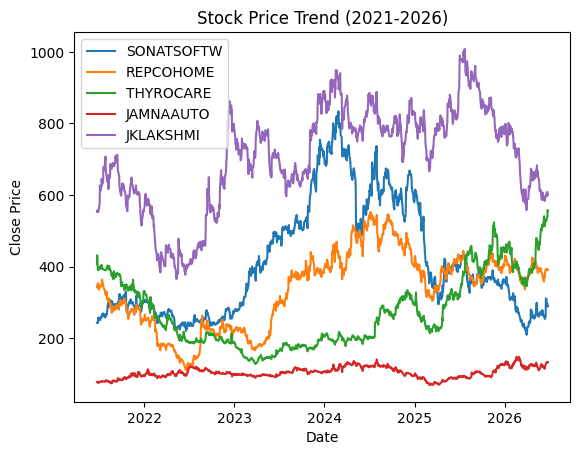

In [19]:
# price trend for all 5 stocks — shows how each stock moved from 2021 to 2026
for s in df10:
    data = df[df['symbol']==s]
    plt.plot(data['date'], data['close'], label=s)
plt.xlabel('Date'); plt.ylabel('Close Price')
plt.title('Stock Price Trend (2021-2026)')
plt.legend(); plt.show()

In [20]:
# daily return = % change in price from previous day
# groupby ensures each stock's return is calculated independently (not across stocks)
df['daily_return'] = df.groupby('symbol')['close'].pct_change() * 100
df[['symbol','date','close','daily_return']].head()

,symbol,date,close,daily_return
613338,JAMNAAUTO,2021-06-24,77.516457,NaN
613339,JAMNAAUTO,2021-06-25,76.919479,-0.770130
613340,JAMNAAUTO,2021-06-28,75.771416,-1.492553
613341,JAMNAAUTO,2021-06-29,75.266281,-0.666656
613342,JAMNAAUTO,2021-06-30,77.746071,3.294689


In [21]:
# mean daily return per stock — higher value = stock grew more on average each day
df.groupby('symbol')['daily_return'].mean()

,daily_return
symbol,
JAMNAAUTO,0.069926
JKLAKSHMI,0.030522
REPCOHOME,0.047648
SONATSOFTW,0.048649
THYROCARE,0.052518


In [22]:
# std dev of daily return = volatility — higher = more risky / more unstable
df.groupby('symbol')['daily_return'].std()

,daily_return
symbol,
JAMNAAUTO,2.317035
JKLAKSHMI,2.199345
REPCOHOME,2.735361
SONATSOFTW,2.640327
THYROCARE,2.356841


 Moving Averages, Volatility, Distribution

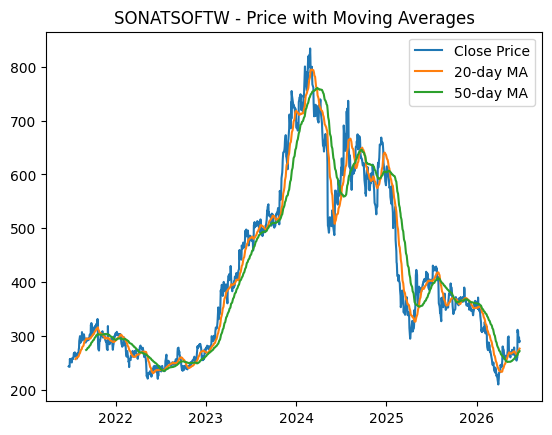

In [23]:
# moving average smooths out daily noise and shows the underlying trend
# when price crosses above MA50 = bullish; crosses below = bearish
stock = 'SONATSOFTW'
data = df[df['symbol']==stock].sort_values('date').reset_index(drop=True)
data['MA20'] = data['close'].rolling(20).mean()    # avg of last 20 days
data['MA50'] = data['close'].rolling(50).mean()    # avg of last 50 days

plt.plot(data['date'], data['close'], label='Close Price')
plt.plot(data['date'], data['MA20'],  label='20-day MA')
plt.plot(data['date'], data['MA50'],  label='50-day MA')
plt.title(f'{stock} - Price with Moving Averages')
plt.legend(); plt.show()

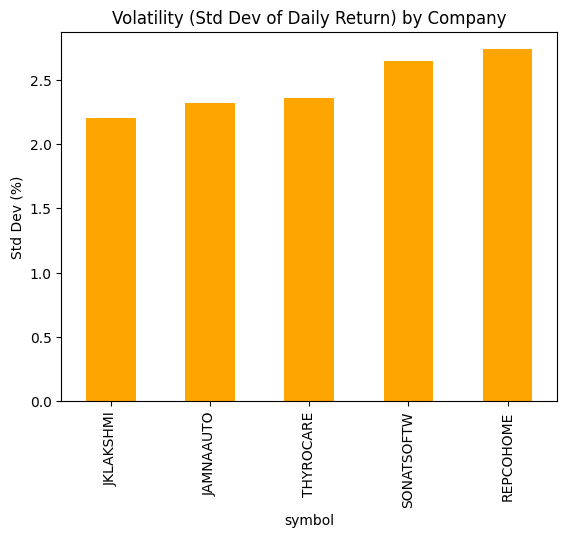

In [24]:
# volatility bar chart — sorted low to high
# higher bar = more day-to-day price swings = higher risk for that stock
volatility = df.groupby('symbol')['daily_return'].std().sort_values()
volatility.plot(kind='bar', color='orange')
plt.title('Volatility (Std Dev of Daily Return) by Company')
plt.ylabel('Std Dev (%)'); plt.show()

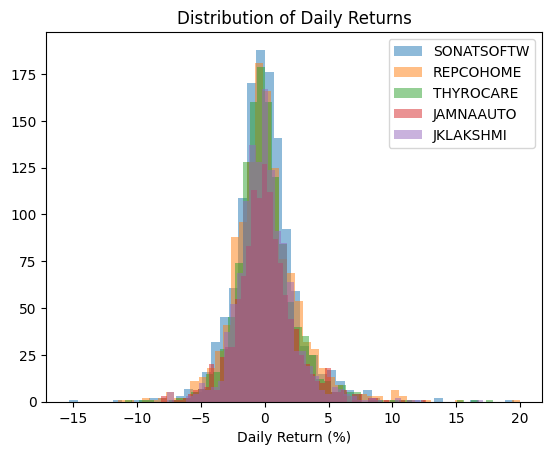

In [25]:
# histogram of daily returns — bell shape centered at 0 is ideal
# fat tails = extreme return days happened (crashes or surges)
for s in df10:
    plt.hist(df[df['symbol']==s]['daily_return'].dropna(), bins=50, alpha=0.5, label=s)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)'); plt.legend(); plt.show()

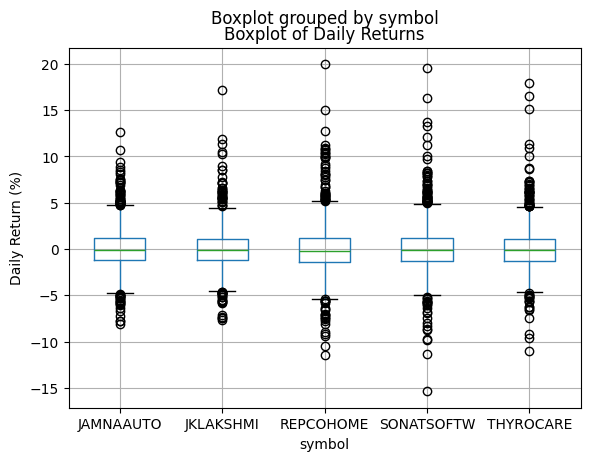

In [26]:
# boxplot — shows median, IQR, and outlier days per stock
# wider box = more volatile; dots beyond whiskers = extreme return days
df.boxplot(column='daily_return', by='symbol')
plt.title('Boxplot of Daily Returns'); plt.ylabel('Daily Return (%)'); plt.show()

Correlation, Volume & Growth

In [27]:
# pivot makes date the index and each stock a column — needed for corr()
# high correlation between two stocks = they move together (driven by same macro factor)
return_pivot = df.pivot(index='date', columns='symbol', values='daily_return')
correlation  = return_pivot.corr()
correlation

symbol,JAMNAAUTO,JKLAKSHMI,REPCOHOME,SONATSOFTW,THYROCARE
symbol,,,,,
JAMNAAUTO,1.000000,0.230559,0.273410,0.226089,0.158614
JKLAKSHMI,0.230559,1.000000,0.205773,0.186128,0.136482
REPCOHOME,0.273410,0.205773,1.000000,0.200703,0.165426
SONATSOFTW,0.226089,0.186128,0.200703,1.000000,0.130486
THYROCARE,0.158614,0.136482,0.165426,0.130486,1.000000


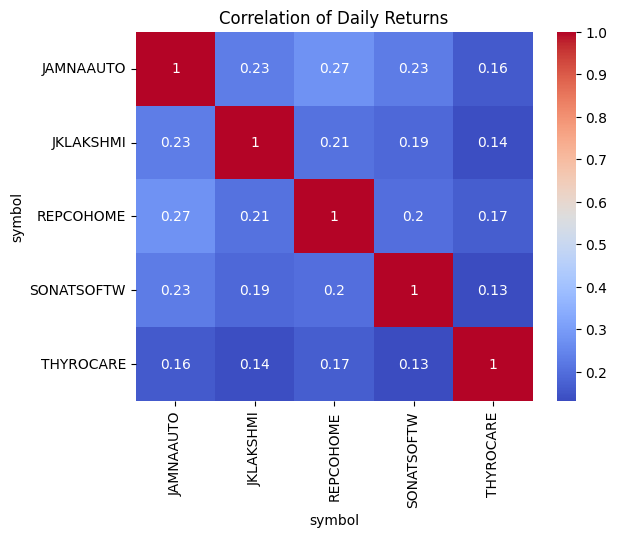

In [28]:
# heatmap visualises the correlation matrix — red = positive, blue = negative
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation of Daily Returns'); plt.show()

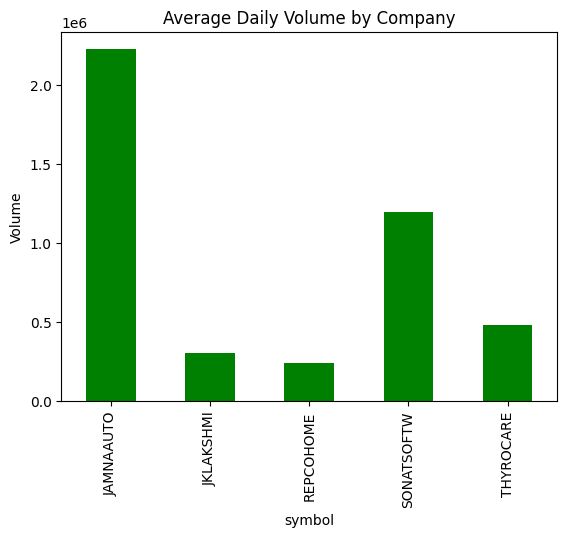

In [29]:
# avg daily trading volume — higher = more liquid stock (easier to buy/sell without moving price)
avg_volume = df.groupby('symbol')['volume'].mean()
avg_volume.plot(kind='bar', color='green')
plt.title('Average Daily Volume by Company'); plt.ylabel('Volume'); plt.show()

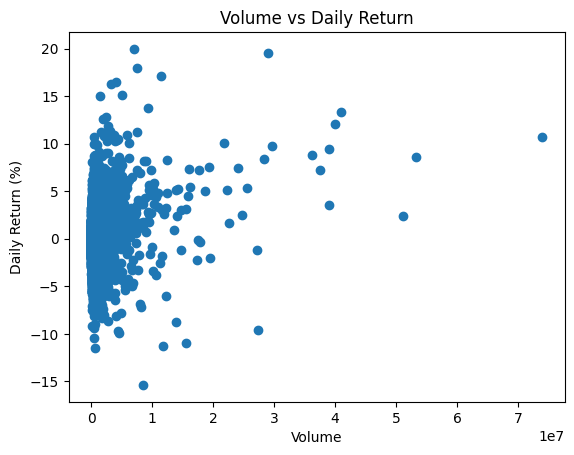

In [30]:
# scatter: does higher volume cause bigger returns? — usually weak or no relationship
plt.scatter(df['volume'], df['daily_return'])
plt.xlabel('Volume'); plt.ylabel('Daily Return (%)')
plt.title('Volume vs Daily Return'); plt.show()

In [31]:
# highest and lowest close price day for each stock over the full 5-year period
for s in df10:
    data = df[df['symbol']==s]
    max_row = data.loc[data['close'].idxmax()]
    min_row = data.loc[data['close'].idxmin()]
    print(s, '-> Highest:', round(max_row['close'],2), 'on', max_row['date'].date(),
          '| Lowest:', round(min_row['close'],2), 'on', min_row['date'].date())

SONATSOFTW -> Highest: 834.12 on 2024-02-27 | Lowest: 209.6 on 2026-03-30
REPCOHOME -> Highest: 552.85 on 2024-07-05 | Lowest: 108.98 on 2022-06-23
THYROCARE -> Highest: 558.4 on 2026-06-23 | Lowest: 127.74 on 2023-03-28
JAMNAAUTO -> Highest: 148.25 on 2026-02-26 | Lowest: 69.49 on 2025-03-04
JKLAKSHMI -> Highest: 1008.35 on 2025-07-22 | Lowest: 365.35 on 2022-05-12


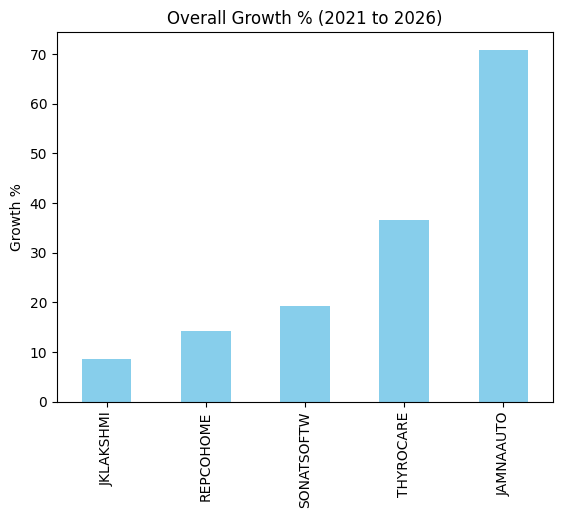

,0
JKLAKSHMI,8.635272
REPCOHOME,14.315697
SONATSOFTW,19.253613
THYROCARE,36.613132
JAMNAAUTO,70.841133


In [32]:
# 5-year total growth % = (last price - first price) / first price * 100
growth = {}
for s in df10:
    data = df[df['symbol']==s].sort_values('date')
    growth[s] = (data['close'].iloc[-1] - data['close'].iloc[0]) / data['close'].iloc[0] * 100

growth_series = pd.Series(growth).sort_values()
growth_series.plot(kind='bar', color='skyblue')
plt.title('Overall Growth % (2021 to 2026)'); plt.ylabel('Growth %'); plt.show()
growth_series

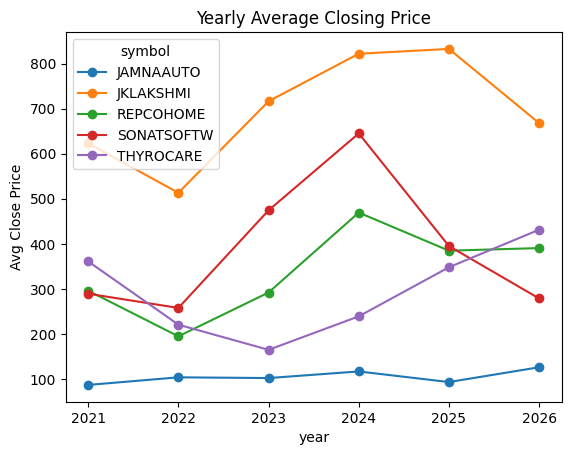

symbol,JAMNAAUTO,JKLAKSHMI,REPCOHOME,SONATSOFTW,THYROCARE
year,,,,,
2021,86.651622,622.907408,295.845954,289.137849,360.871571
2022,103.510869,513.238712,194.545695,257.561844,220.422483
2023,101.922685,716.398625,291.819369,474.299397,164.588178
2024,116.572969,822.014893,469.311570,645.082920,238.868293
2025,92.999987,832.670631,384.705278,394.992654,347.889565
2026,125.856722,667.998317,390.468012,278.636841,431.300510


In [33]:
# yearly average closing price — shows which year was best/worst for each stock
df['year'] = df['date'].dt.year
yearly_avg = df.groupby(['symbol','year'])['close'].mean().unstack(level=0)
yearly_avg.plot(kind='line', marker='o')
plt.title('Yearly Average Closing Price'); plt.ylabel('Avg Close Price'); plt.show()
yearly_avg

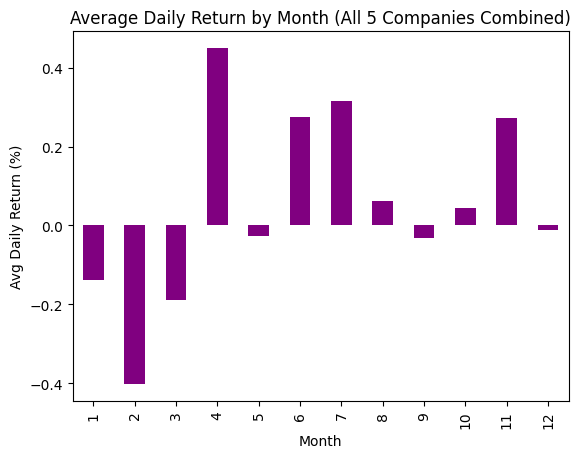

In [34]:
# monthly avg return — which calendar months are typically best/worst across all 5 stocks?
df['month'] = df['date'].dt.month
monthly_avg_return = df.groupby('month')['daily_return'].mean()
monthly_avg_return.plot(kind='bar', color='purple')
plt.title('Average Daily Return by Month (All 5 Companies Combined)')
plt.xlabel('Month'); plt.ylabel('Avg Daily Return (%)'); plt.show()

In [35]:
# best and worst single trading day for each stock
for s in df10:
    data = df[df['symbol']==s]
    best  = data.loc[data['daily_return'].idxmax()]
    worst = data.loc[data['daily_return'].idxmin()]
    print(s, '-> Best day:', round(best['daily_return'],2), '% on', best['date'].date(),
          '| Worst day:', round(worst['daily_return'],2), '% on', worst['date'].date())

SONATSOFTW -> Best day: 19.55 % on 2026-06-16 | Worst day: -15.38 % on 2024-05-08
REPCOHOME -> Best day: 19.98 % on 2022-08-19 | Worst day: -11.49 % on 2022-02-15
THYROCARE -> Best day: 17.93 % on 2024-07-24 | Worst day: -10.99 % on 2022-12-22
JAMNAAUTO -> Best day: 12.64 % on 2021-12-07 | Worst day: -8.1 % on 2024-06-04
JKLAKSHMI -> Best day: 17.13 % on 2022-05-20 | Worst day: -7.65 % on 2023-07-28


 Quarterly Results & Financial Ratios

In [36]:
# quarterly results for our 5 stocks — revenue, net income, EPS per quarter
qr = df5.copy()
qr['date'] = pd.to_datetime(qr['date'])
qr = qr[qr['symbol'].isin(df10)]
qr[['symbol','date','total_revenue','net_income','eps_diluted']]

,symbol,date,total_revenue,net_income,eps_diluted
3286,JAMNAAUTO,2026-03-31,8.396005e+09,8.726560e+08,2.180000
3287,JAMNAAUTO,2025-12-31,6.677858e+09,5.823200e+08,1.460000
3288,JAMNAAUTO,2025-09-30,5.308750e+09,3.973650e+08,1.000000
3289,JAMNAAUTO,2025-06-30,5.733260e+09,4.574500e+08,1.140000
3290,JAMNAAUTO,2025-03-31,6.377135e+09,5.031900e+08,1.260000
3291,JAMNAAUTO,2024-12-31,NaN,NaN,NaN
3292,JAMNAAUTO,2024-09-30,NaN,NaN,NaN
3387,JKLAKSHMI,2026-03-31,1.901530e+10,1.240600e+09,9.990000
3388,JKLAKSHMI,2025-12-31,1.588400e+10,5.692000e+08,4.580000
3389,JKLAKSHMI,2025-09-30,NaN,NaN,NaN


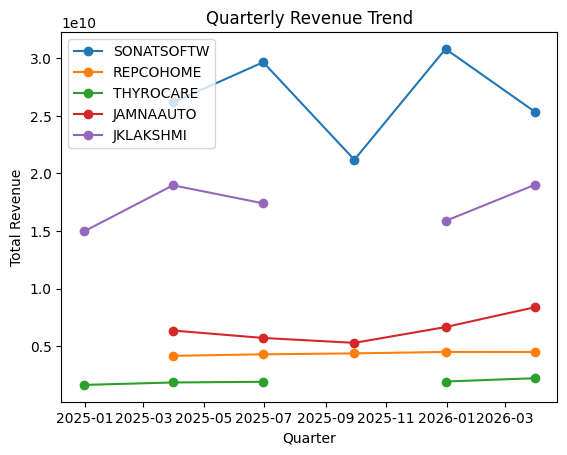

In [37]:
# revenue trend — which stock is growing its top line quarter by quarter?
for s in df10:
    data = qr[qr['symbol']==s].sort_values('date')
    plt.plot(data['date'], data['total_revenue'], marker='o', label=s)
plt.title('Quarterly Revenue Trend'); plt.xlabel('Quarter')
plt.ylabel('Total Revenue'); plt.legend(); plt.show()

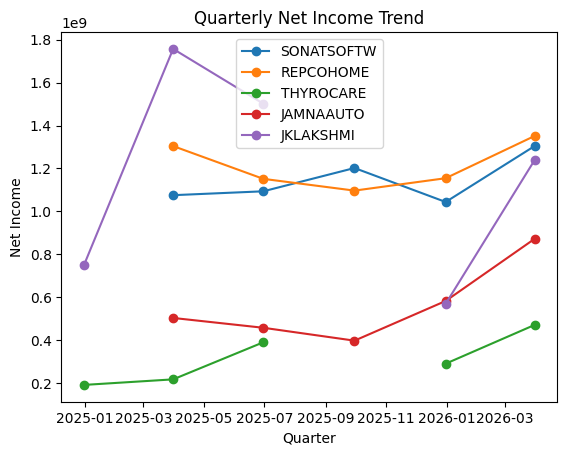

In [38]:
# net income trend — profitability over time per stock
for s in df10:
    data = qr[qr['symbol']==s].sort_values('date')
    plt.plot(data['date'], data['net_income'], marker='o', label=s)
plt.title('Quarterly Net Income Trend'); plt.xlabel('Quarter')
plt.ylabel('Net Income'); plt.legend(); plt.show()

In [39]:
# QoQ = quarter-over-quarter growth in net income
# pct_change() compares each quarter to the previous quarter within the same stock
qr = qr.sort_values(['symbol','date'])
qr['net_income_qoq_%'] = qr.groupby('symbol')['net_income'].pct_change() * 100
qr[['symbol','date','net_income','net_income_qoq_%']]

,symbol,date,net_income,net_income_qoq_%
3292,JAMNAAUTO,2024-09-30,NaN,NaN
3291,JAMNAAUTO,2024-12-31,NaN,NaN
3290,JAMNAAUTO,2025-03-31,5.031900e+08,NaN
3289,JAMNAAUTO,2025-06-30,4.574500e+08,-9.090006
3288,JAMNAAUTO,2025-09-30,3.973650e+08,-13.134769
3287,JAMNAAUTO,2025-12-31,5.823200e+08,46.545368
3286,JAMNAAUTO,2026-03-31,8.726560e+08,49.858497
3392,JKLAKSHMI,2024-12-31,7.493000e+08,NaN
3391,JKLAKSHMI,2025-03-31,1.756900e+09,134.472174
3390,JKLAKSHMI,2025-06-30,1.501700e+09,-14.525585


In [40]:
# latest financial ratios — groupby+last() picks the most recent quarter per stock
fr = df4.copy()
fr['date'] = pd.to_datetime(fr['date'])
fr = fr[fr['symbol'].isin(df10)]
latest_ratios = fr.sort_values('date').groupby('symbol').last()
latest_ratios[['pe_ratio','roe_pct','roa_pct','debt_to_equity','net_profit_margin_pct']]

,pe_ratio,roe_pct,roa_pct,debt_to_equity,net_profit_margin_pct
symbol,,,,,
JAMNAAUTO,22.951471,30.43,21.18,0.010385,10.39
JKLAKSHMI,18.104280,12.77,5.81,0.665473,6.52
REPCOHOME,5.143421,13.38,3.29,3.020744,29.95
SONATSOFTW,17.323776,27.41,10.25,0.379617,5.15
THYROCARE,54.383560,32.19,25.22,0.086576,21.04


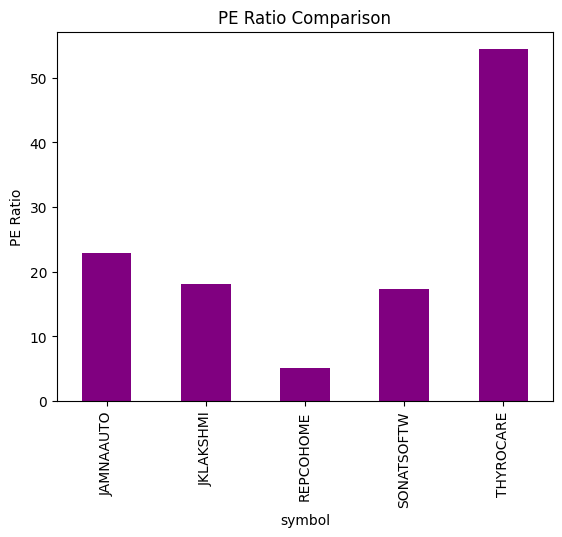

In [41]:
# PE ratio = how much investors pay per rupee of earnings — lower can mean undervalued
latest_ratios['pe_ratio'].plot(kind='bar', color='purple')
plt.title('PE Ratio Comparison'); plt.ylabel('PE Ratio'); plt.show()

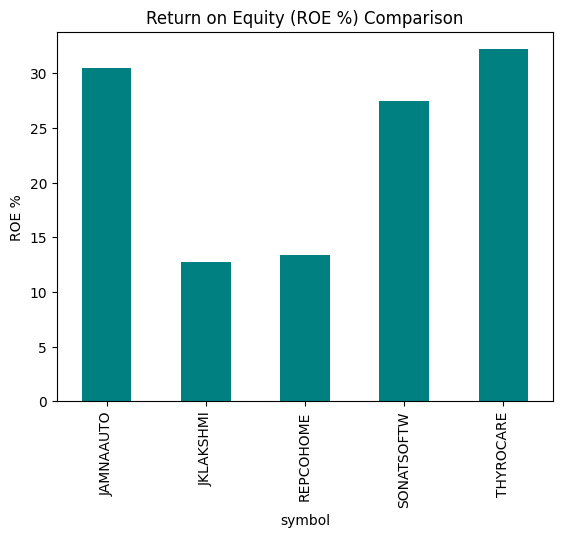

In [42]:
# ROE = return on equity — how efficiently is the company using shareholder money?
latest_ratios['roe_pct'].plot(kind='bar', color='teal')
plt.title('Return on Equity (ROE %) Comparison'); plt.ylabel('ROE %'); plt.show()

In [43]:
# company overview — market cap, beta, promoter & institutional holding
# beta > 1 = stock moves more than market; beta < 1 = more stable than market
ov5 = df8[df8['symbol'].isin(df10)].set_index('symbol')
ov5[['company_name','sector','market_cap_crore','beta','promoter_holding','institutional_holding']]

,company_name,sector,market_cap_crore,beta,promoter_holding,institutional_holding
symbol,,,,,,
JAMNAAUTO,Jamna Auto Industries Limited,Consumer Cyclical,5297.00,0.287,0.53115,0.06780
JKLAKSHMI,JK Lakshmi Cement Limited,Basic Materials,7457.36,0.378,0.47206,0.31146
REPCOHOME,Repco Home Finance Limited,Financial Services,2445.52,0.408,0.37134,0.30762
SONATSOFTW,Sonata Software Limited,Technology,8027.04,0.421,0.43362,0.30596
THYROCARE,Thyrocare Technologies Limited,Healthcare,8846.21,0.467,0.61090,0.21424


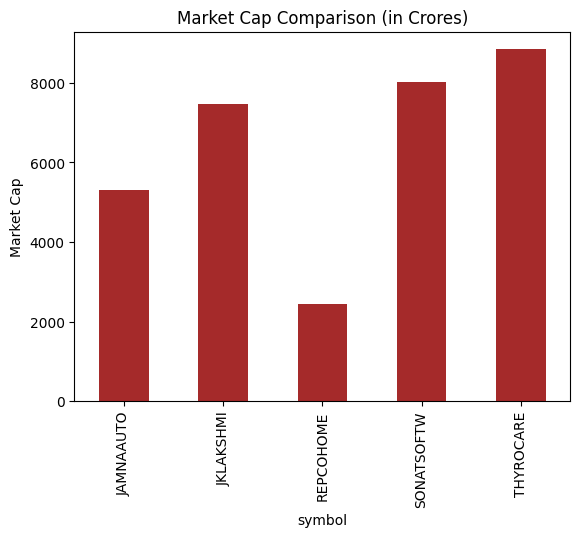

In [44]:
# market cap = total value of the company — shows size and importance of each stock
ov5['market_cap_crore'].plot(kind='bar', color='brown')
plt.title('Market Cap Comparison (in Crores)'); plt.ylabel('Market Cap'); plt.show()

 Feature Engineering

In [45]:
# filter to one stock, sort by date, assign a numeric day index
# day_number = 0,1,2... replaces date column so OLS can use it as a numeric predictor
stock = 'SONATSOFTW'
data  = df[df['symbol']==stock].sort_values('date').reset_index(drop=True)
data['day_number'] = np.arange(len(data))

In [46]:
# engineer new features to give the model richer signals than raw OHLCV alone
# rolling(N).mean() = moving average over last N days
# shift(N) = price N days ago (lag feature — yesterday is the best predictor of today)
for w in [5,10,20,50]:
    data[f'MA{w}'] = data['close'].rolling(w).mean()     # moving averages

data['HL_spread']   = data['high'] - data['low']         # intraday price range
data['OC_diff']     = data['close'] - data['open']       # open-to-close move
data['vol_ma5']     = data['volume'].rolling(5).mean()   # smoothed volume (less noisy)
data['lag1']        = data['close'].shift(1)             # yesterday's close price
data['lag2']        = data['close'].shift(2)             # 2 days ago
data['lag5']        = data['close'].shift(5)             # 5 days ago
data['daily_return']= data['close'].pct_change() * 100
data['volatility5'] = data['daily_return'].rolling(5).std()  # 5-day rolling risk

data.dropna(inplace=True)    # first few rows have NaN from rolling/shift — remove them
data.head()

,symbol,date,open,high,low,close,adj_close,volume,daily_return,year,month,day_number,MA5,MA10,MA20,MA50,HL_spread,OC_diff,vol_ma5,lag1,lag2,lag5,volatility5
49,SONATSOFTW,2021-09-03,290.329930,296.776327,289.192311,295.035461,295.035461,841869.0,2.117898,2021,9,49,290.247156,294.797580,294.578671,273.743627,7.584016,4.705532,641791.0,288.916504,287.520325,295.948975,1.469470
50,SONATSOFTW,2021-09-06,296.810753,299.930530,293.018746,294.294250,294.294250,1184533.0,-0.251228,2021,9,50,290.698755,294.694156,294.776025,274.765928,6.911784,-2.516503,712991.0,295.035461,288.916504,292.036255,1.307397
51,SONATSOFTW,2021-09-07,294.742457,294.742457,290.640199,291.967407,291.967407,357722.0,-0.790652,2021,9,51,291.546790,293.609991,294.401999,275.752249,4.102258,-2.775049,667729.6,294.294250,295.035461,287.727234,1.114772
52,SONATSOFTW,2021-09-08,291.295100,294.828561,288.227027,290.915894,290.915894,318767.0,-0.360148,2021,9,52,292.225903,292.425845,294.216704,276.724348,6.601534,-0.379206,626005.2,291.967407,294.294250,287.520325,1.145703
53,SONATSOFTW,2021-09-09,289.881774,295.000991,289.881774,294.725220,294.725220,764287.0,1.309425,2021,9,53,293.387646,291.908752,294.597632,277.480152,5.119216,4.843445,693435.6,290.915894,291.967407,288.916504,1.244756


Drop Useless Columns

In [47]:
# correlation of each column with close price
# columns with corr > 0.95 are near-duplicates of close — they add noise, not signal
numeric_data     = data.select_dtypes(include=[np.number])
corr_with_close  = numeric_data.corr()['close'].abs().sort_values(ascending=False)
corr_with_close

,close
adj_close,1.000000
close,1.000000
high,0.999140
low,0.998836
open,0.997633
lag1,0.997245
MA5,0.996447
lag2,0.994285
MA10,0.991838
lag5,0.985201


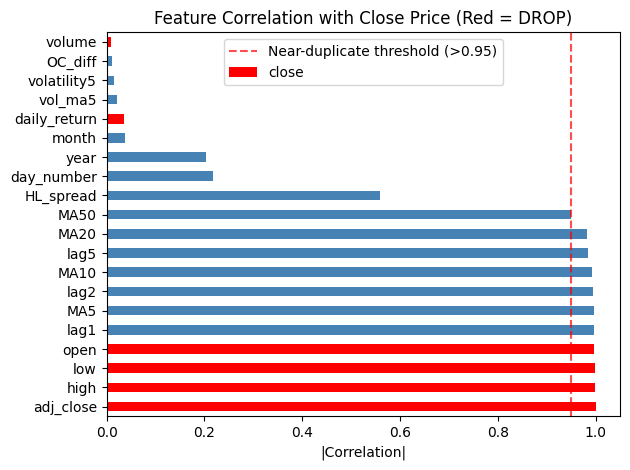

In [48]:
# red bars = columns to drop | blue bars = columns to keep
drop_set = {'adj_close','high','low','open','volume','daily_return'}
colors = ['red' if f in drop_set else 'steelblue' for f in corr_with_close.drop('close').index]
corr_with_close.drop('close').plot(kind='barh', color=colors)
plt.axvline(0.95, color='red', linestyle='--', alpha=0.7, label='Near-duplicate threshold (>0.95)')
plt.title('Feature Correlation with Close Price (Red = DROP)')
plt.xlabel('|Correlation|'); plt.legend(); plt.tight_layout(); plt.show()

In [49]:
# DROP REASONS (each on one line — no need for a print block):
# symbol       → text identifier, model cannot learn from a stock name
# date         → replaced by day_number (clean numeric time index)
# adj_close    → corr = 1.0 with close — pure duplicate, causes multicollinearity
# high, low    → replaced by HL_spread (high - low) — raw values collinear with close
# open         → replaced by OC_diff (close - open) — raw value collinear with close
# volume       → replaced by vol_ma5 (5-day smoothed) — raw volume is too noisy
# daily_return → computed FROM close — using it would leak the target into predictors

drop_cols    = ['symbol','date','adj_close','high','low','open','volume','daily_return']
feat_df      = data.drop(columns=[c for c in drop_cols if c in data.columns])
feature_cols = [c for c in feat_df.columns if c != 'close']    # all columns except response
feat_df.head()

,close,year,month,day_number,MA5,MA10,MA20,MA50,HL_spread,OC_diff,vol_ma5,lag1,lag2,lag5,volatility5
49,295.035461,2021,9,49,290.247156,294.797580,294.578671,273.743627,7.584016,4.705532,641791.0,288.916504,287.520325,295.948975,1.469470
50,294.294250,2021,9,50,290.698755,294.694156,294.776025,274.765928,6.911784,-2.516503,712991.0,295.035461,288.916504,292.036255,1.307397
51,291.967407,2021,9,51,291.546790,293.609991,294.401999,275.752249,4.102258,-2.775049,667729.6,294.294250,295.035461,287.727234,1.114772
52,290.915894,2021,9,52,292.225903,292.425845,294.216704,276.724348,6.601534,-0.379206,626005.2,291.967407,294.294250,287.520325,1.145703
53,294.725220,2021,9,53,293.387646,291.908752,294.597632,277.480152,5.119216,4.843445,693435.6,290.915894,291.967407,288.916504,1.244756


 VIF Check (Multicollinearity)

In [50]:
# VIF (Variance Inflation Factor) — measures how correlated each predictor is with others
# VIF < 10 = OK | VIF 10-100 = high | VIF > 100 = extreme (collinear)
# MA5/MA10/MA20/MA50/lag1/lag2/lag5 will all have high VIF — they all track price level
# For tree models (DT/RF/XGB): VIF has NO effect — trees use splits not linear combinations
# For OLS: high VIF inflates standard errors but R2 prediction is still valid

X_check  = feat_df[feature_cols].copy()
vif_data = pd.DataFrame()
vif_data['feature'] = X_check.columns
vif_data['VIF']     = [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,feature,VIF
3,MA5,18488.644811
4,MA10,10819.611688
11,lag2,4700.118806
10,lag1,4123.676190
5,MA20,2705.555329
12,lag5,2495.357961
6,MA50,338.384259
0,year,16.919034
7,HL_spread,6.077788
13,volatility5,5.766771


Train-Test Split

In [51]:
X = feat_df[feature_cols]
y = feat_df['close']

# shuffle=False keeps chronological order: train = early dates, test = recent dates
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows  |  Features: {X.shape[1]}")

Train: 951 rows  |  Test: 238 rows  |  Features: 14


Linear Regression

In [52]:
# add_constant adds a column of 1s so OLS can estimate the intercept term (c)
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

ols_model  = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  close   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.170e+04
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:36:14   Log-Likelihood:                -2969.6
No. Observations:                 951   AIC:                             5969.
Df Residuals:                     936   BIC:                             6042.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.311e+04   1.49e+04      0.880      

In [53]:
# predict on train and test sets, then compute R² and RMSE
# R²: closer to 1 = better | RMSE: lower = better (in INR — same units as close price)
# ols_gap: small gap = model generalises well to unseen data (good fit)
y_pred_train_ols = ols_model.predict(X_train_sm)
y_pred_test_ols  = ols_model.predict(X_test_sm)

ols_train_r2   = r2_score(y_train, y_pred_train_ols)
ols_test_r2    = r2_score(y_test,  y_pred_test_ols)
ols_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_ols))
ols_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test_ols))
ols_gap        = abs(ols_train_r2 - ols_test_r2)

print(f"Train R2: {ols_train_r2:.4f}  |  Test R2: {ols_test_r2:.4f}  |  Gap: {ols_gap:.4f}")
print(f"Train RMSE: INR {ols_train_rmse:.2f}  |  Test RMSE: INR {ols_test_rmse:.2f}")

Train R2: 0.9989  |  Test R2: 0.9976  |  Gap: 0.0014
Train RMSE: INR 5.49  |  Test RMSE: INR 2.68


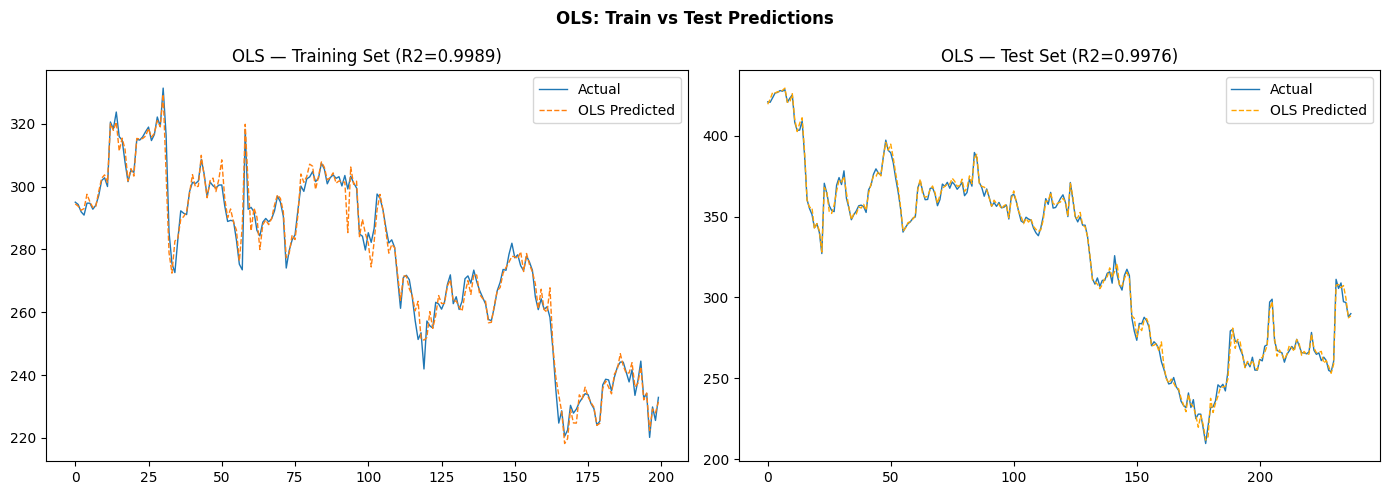

In [54]:
# actual vs predicted — if dashed line tracks solid line closely = good model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(y_train.values[:200], label='Actual', linewidth=1)
axes[0].plot(y_pred_train_ols.values[:200], '--', label='OLS Predicted', linewidth=1)
axes[0].set_title(f'OLS — Training Set (R2={ols_train_r2:.4f})')
axes[0].legend()

axes[1].plot(y_test.values, label='Actual', linewidth=1)
axes[1].plot(y_pred_test_ols.values, '--', color='orange', label='OLS Predicted', linewidth=1)
axes[1].set_title(f'OLS — Test Set (R2={ols_test_r2:.4f})')
axes[1].legend()

plt.suptitle('OLS: Train vs Test Predictions', fontweight='bold')
plt.tight_layout(); plt.show()

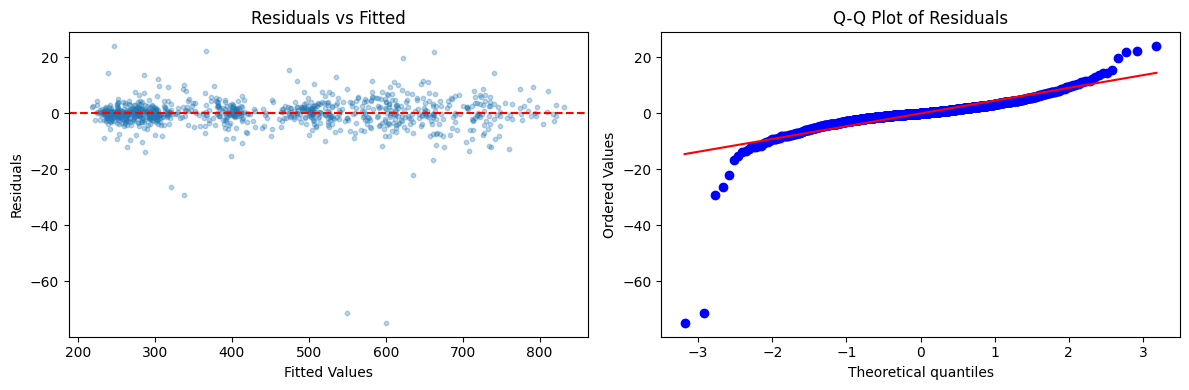

In [55]:
# residual plots check OLS assumptions:
# left — residuals vs fitted: no fan shape = constant variance (homoscedasticity) = good
# right — Q-Q plot: points on diagonal line = residuals are normally distributed = good
residuals_train = y_train - y_pred_train_ols

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_train_ols, residuals_train, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

probplot(residuals_train, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
plt.tight_layout(); plt.show()

Decision Tree Regressor

In [56]:
# WITHOUT constraints — tree grows until every leaf has 1 sample
# train R2 = 1.0 (memorised every row) but test R2 is very low = classic overfitting
dt_overfit = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_overfit.fit(X_train, y_train)

dt_of_tr = r2_score(y_train, dt_overfit.predict(X_train))
dt_of_te = r2_score(y_test,  dt_overfit.predict(X_test))

print(f"Overfit Tree — Train R2: {dt_of_tr:.4f}  |  Test R2: {dt_of_te:.4f}  |  Gap: {abs(dt_of_tr-dt_of_te):.4f}")
# huge gap = model memorised training noise, failed on unseen data

Overfit Tree — Train R2: 1.0000  |  Test R2: 0.9237  |  Gap: 0.0763


In [57]:
# TUNED TREE — hyperparameters control depth and minimum samples per node
# max_depth=7: tree cannot grow beyond 7 levels (prevents memorising noise)
# min_samples_split=20: a node needs 20+ samples before it can split further
# min_samples_leaf=10: each final leaf needs 10+ samples (no single-row leaves)
dt_tuned = DecisionTreeRegressor(max_depth=7, min_samples_split=20, min_samples_leaf=10, random_state=42)
dt_tuned.fit(X_train, y_train)

y_pred_train_dt = dt_tuned.predict(X_train)
y_pred_test_dt  = dt_tuned.predict(X_test)

dt_train_r2   = r2_score(y_train, y_pred_train_dt)
dt_test_r2    = r2_score(y_test,  y_pred_test_dt)
dt_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_dt))
dt_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test_dt))
dt_gap        = abs(dt_train_r2 - dt_test_r2)

print(f"Tuned Tree  — Train R2: {dt_train_r2:.4f}  |  Test R2: {dt_test_r2:.4f}  |  Gap: {dt_gap:.4f}")
# gap should be much smaller than the overfit tree above

Tuned Tree  — Train R2: 0.9970  |  Test R2: 0.9550  |  Gap: 0.0420


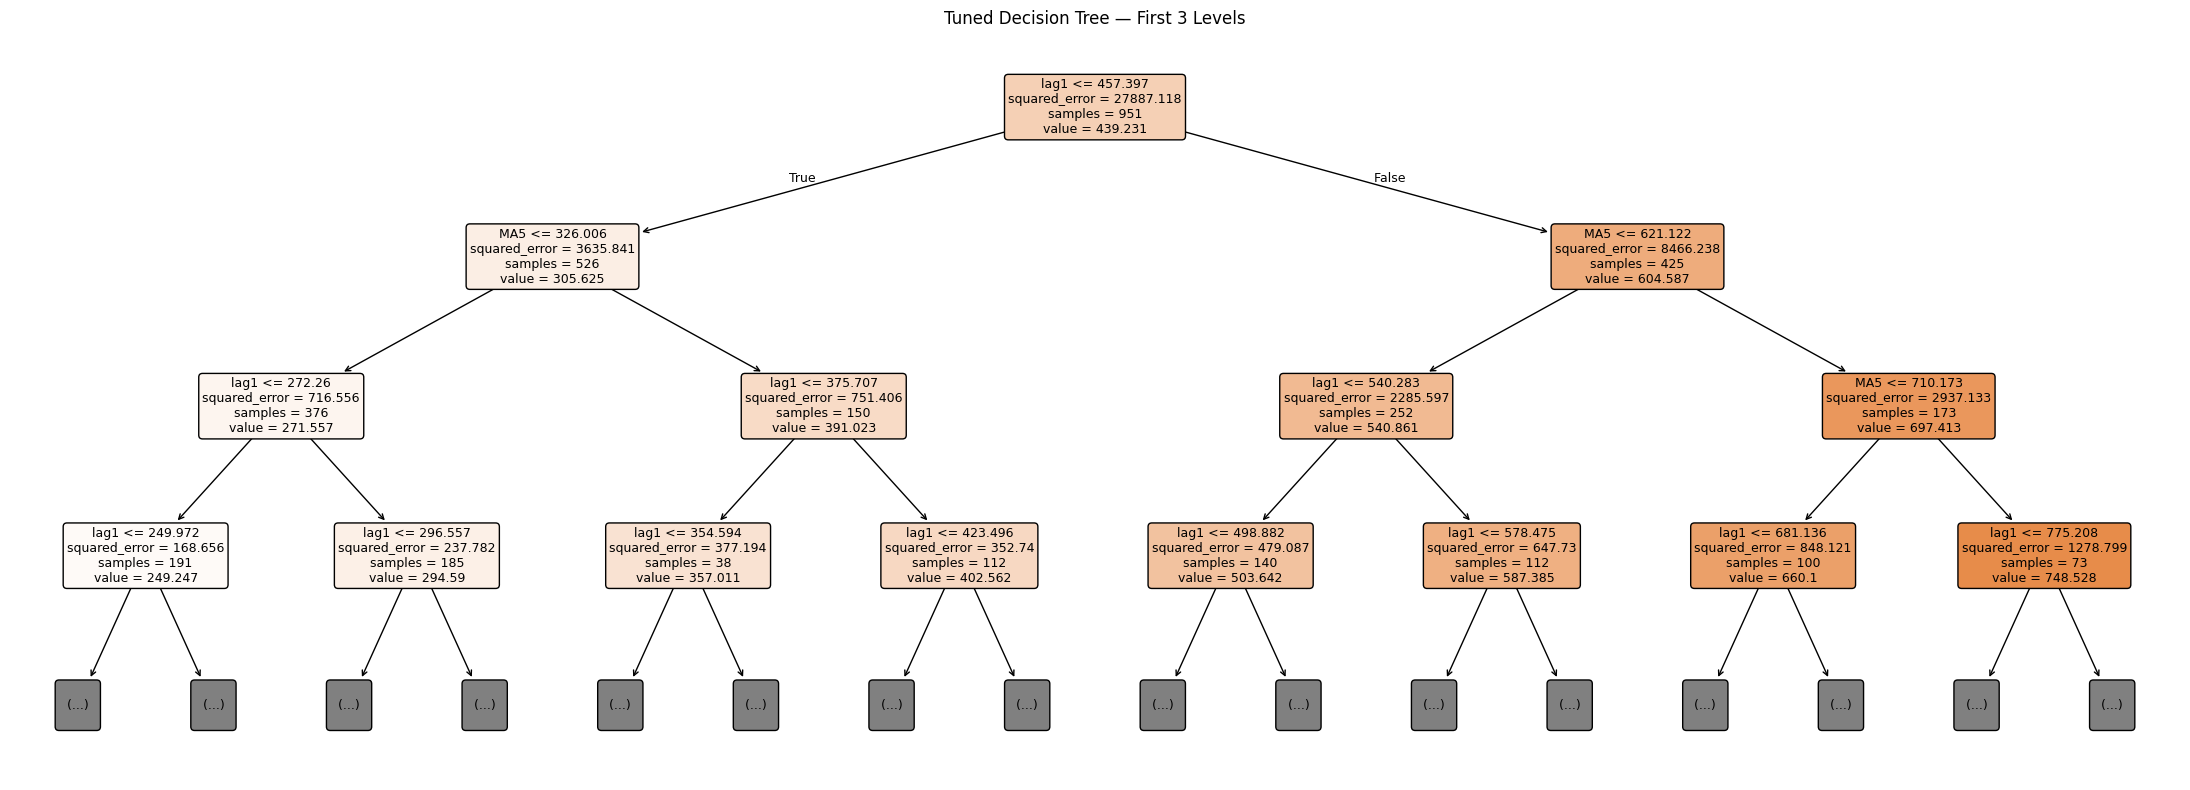

In [58]:
# visualise first 3 levels of the tuned tree
# each node shows: split condition, number of samples, and predicted value
plt.figure(figsize=(22, 8))
plot_tree(dt_tuned, max_depth=3, feature_names=feature_cols, filled=True, rounded=True, fontsize=9)
plt.title('Tuned Decision Tree — First 3 Levels')
plt.tight_layout(); plt.show()

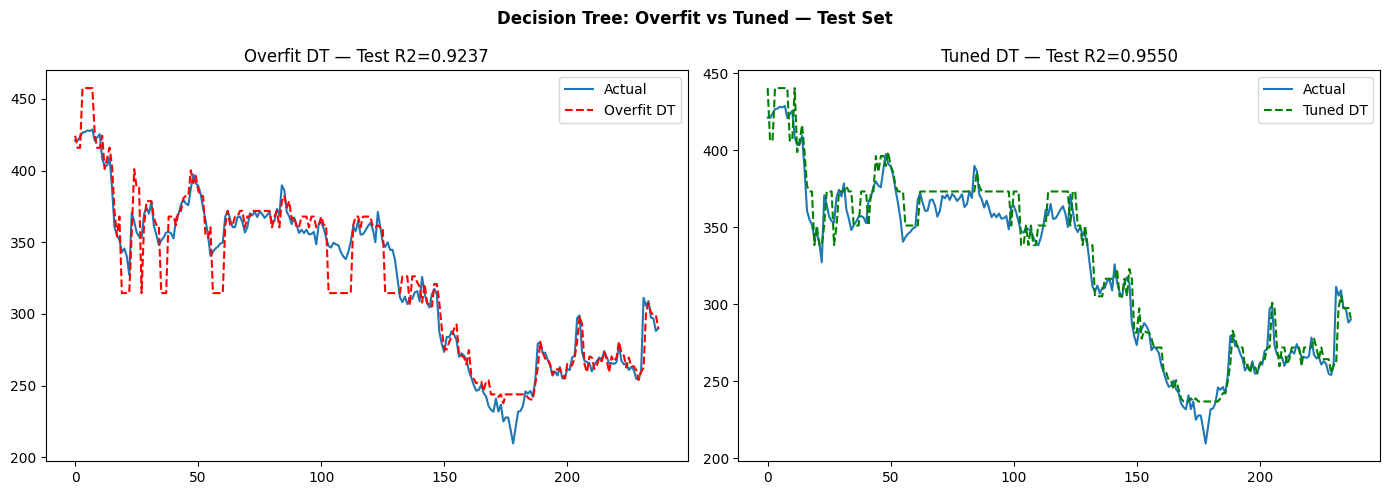

In [59]:
# overfit tree vs tuned tree on test data side by side
# overfit tree gives flat/stepped predictions — it cannot extrapolate beyond training range
# tuned tree tracks actual prices better because it learned patterns, not noise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(y_test.values, label='Actual')
axes[0].plot(dt_overfit.predict(X_test), '--', color='red', label='Overfit DT')
axes[0].set_title(f'Overfit DT — Test R2={dt_of_te:.4f}'); axes[0].legend()

axes[1].plot(y_test.values, label='Actual')
axes[1].plot(y_pred_test_dt, '--', color='green', label='Tuned DT')
axes[1].set_title(f'Tuned DT — Test R2={dt_test_r2:.4f}'); axes[1].legend()

plt.suptitle('Decision Tree: Overfit vs Tuned — Test Set', fontweight='bold')
plt.tight_layout(); plt.show()

Random Forest

In [60]:
# n_estimators=200: build 200 trees and average their predictions
# max_features='sqrt': each tree sees sqrt(n_features) predictors — decorrelates trees
# oob_score=True: uses the ~37% of rows NOT seen by each tree as a free validation score
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=8,
    min_samples_split=10, min_samples_leaf=5,
    max_features='sqrt', oob_score=True,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf  = rf_model.predict(X_test)

rf_train_r2   = r2_score(y_train, y_pred_train_rf)
rf_test_r2    = r2_score(y_test,  y_pred_test_rf)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
rf_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test_rf))
rf_gap        = abs(rf_train_r2 - rf_test_r2)

print(f"RF — Train R2: {rf_train_r2:.4f}  |  Test R2: {rf_test_r2:.4f}  |  OOB: {rf_model.oob_score_:.4f}  |  Gap: {rf_gap:.4f}")

RF — Train R2: 0.9970  |  Test R2: 0.9214  |  OOB: 0.9939  |  Gap: 0.0757


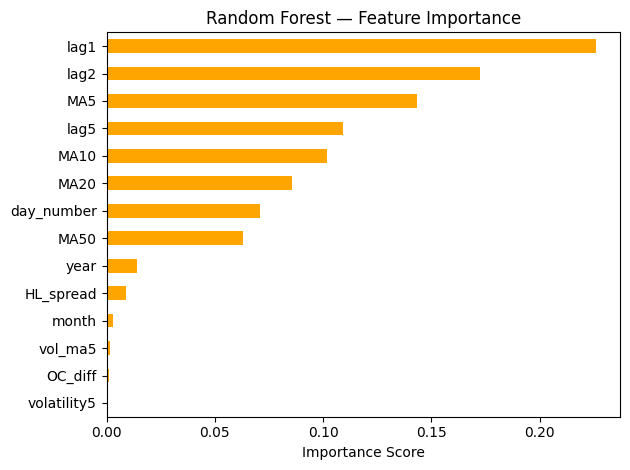

In [61]:
# feature importance — which predictors did the forest rely on most?
# lag1 and MA5 usually dominate because yesterday's price predicts today's price best
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_imp.plot(kind='barh', color='orange')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score'); plt.tight_layout(); plt.show()

 XGBoost

In [62]:
# learning_rate=0.05: small steps = slower but better generalisation (less overfit)
# subsample=0.8: each tree sees 80% of rows — adds randomness like RF
# colsample_bytree=0.8: each tree sees 80% of features
# reg_alpha=0.1: L1 — pushes small leaf weights to 0 (feature selection effect)
# reg_lambda=1.5: L2 — shrinks all leaf weights (reduces overfitting)
xgb_model = xgb.XGBRegressor(
    n_estimators=200, max_depth=5,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.5, min_child_weight=5,
    random_state=42, verbosity=0, tree_method='hist'
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_test, y_test)], verbose=False)

y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb  = xgb_model.predict(X_test)

xgb_train_r2   = r2_score(y_train, y_pred_train_xgb)
xgb_test_r2    = r2_score(y_test,  y_pred_test_xgb)
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
xgb_test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test_xgb))
xgb_gap        = abs(xgb_train_r2 - xgb_test_r2)

print(f"XGB — Train R2: {xgb_train_r2:.4f}  |  Test R2: {xgb_test_r2:.4f}  |  Gap: {xgb_gap:.4f}")

XGB — Train R2: 0.9997  |  Test R2: 0.9851  |  Gap: 0.0146


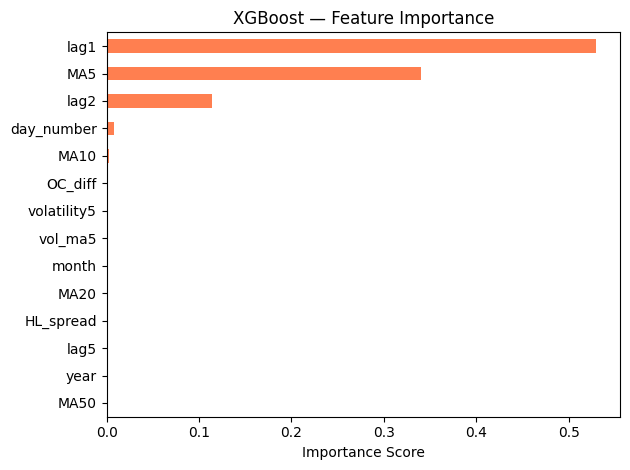

In [63]:
# feature importance — which features drove gradient corrections most across all boosting rounds?
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
xgb_imp.plot(kind='barh', color='coral')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score'); plt.tight_layout(); plt.show()

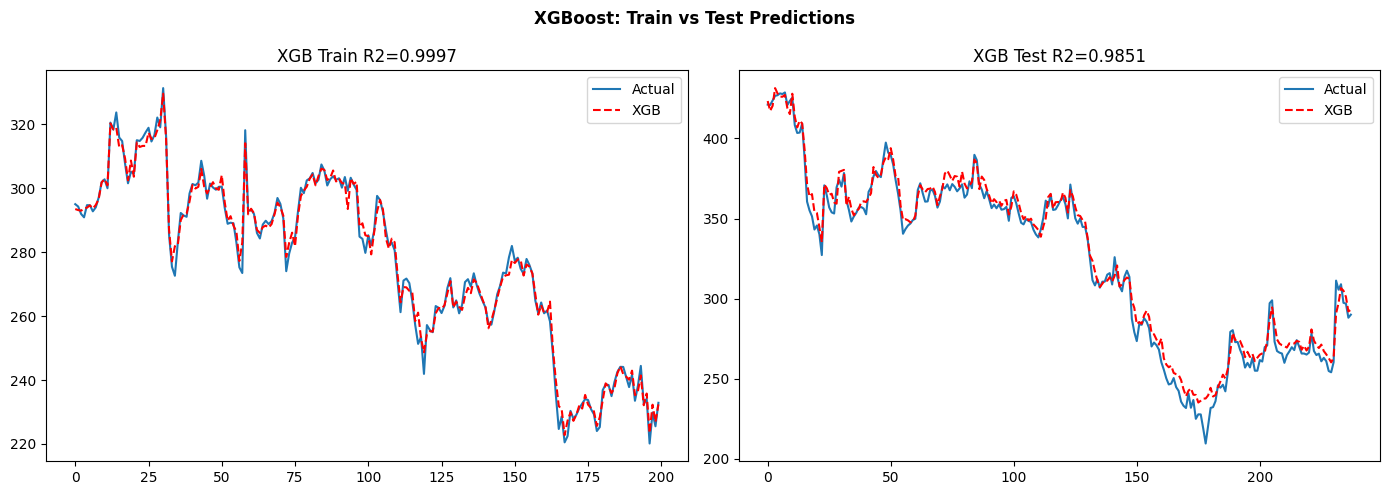

In [64]:
# XGBoost train vs test prediction chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(y_train.values[:200], label='Actual')
axes[0].plot(y_pred_train_xgb[:200], '--', color='red', label='XGB')
axes[0].set_title(f'XGB Train R2={xgb_train_r2:.4f}'); axes[0].legend()

axes[1].plot(y_test.values, label='Actual')
axes[1].plot(y_pred_test_xgb, '--', color='red', label='XGB')
axes[1].set_title(f'XGB Test R2={xgb_test_r2:.4f}'); axes[1].legend()

plt.suptitle('XGBoost: Train vs Test Predictions', fontweight='bold')
plt.tight_layout(); plt.show()

Price Range Check

In [65]:
# if test prices exceed training range, tree models will underperform vs OLS
# fix: predict returns (%) instead of absolute price — returns stay in a bounded range always
print(f"Train range: INR {float(y_train.min()):.2f} – {float(y_train.max()):.2f}")
print(f"Test  range: INR {float(y_test.min()):.2f}  – {float(y_test.max()):.2f}")
# if test_max > train_max → tree models plateau and cannot predict those higher prices

Train range: INR 220.15 – 834.12
Test  range: INR 209.60  – 428.67


 Final Model Comparison Table

In [66]:
# summary table — best model has highest test R2 AND smallest gap (least overfitting)
# RMSE is in INR — tells average prediction error in rupees
comparison = pd.DataFrame({
    'Model'      : ['OLS (Linear)', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Train R2'   : [round(ols_train_r2,4), round(dt_train_r2,4), round(rf_train_r2,4), round(xgb_train_r2,4)],
    'Test R2'    : [round(ols_test_r2,4),  round(dt_test_r2,4),  round(rf_test_r2,4),  round(xgb_test_r2,4)],
    'R2 Gap'     : [round(ols_gap,4),      round(dt_gap,4),      round(rf_gap,4),      round(xgb_gap,4)],
    'Train RMSE' : [round(ols_train_rmse,2),round(dt_train_rmse,2),round(rf_train_rmse,2),round(xgb_train_rmse,2)],
    'Test RMSE'  : [round(ols_test_rmse,2), round(dt_test_rmse,2), round(rf_test_rmse,2), round(xgb_test_rmse,2)]
})
comparison

,Model,Train R2,Test R2,R2 Gap,Train RMSE,Test RMSE
0,OLS (Linear),0.9989,0.9976,0.0014,5.49,2.68
1,Decision Tree,0.9970,0.9550,0.0420,9.15,11.51
2,Random Forest,0.9970,0.9214,0.0757,9.09,15.20
3,XGBoost,0.9997,0.9851,0.0146,2.98,6.62


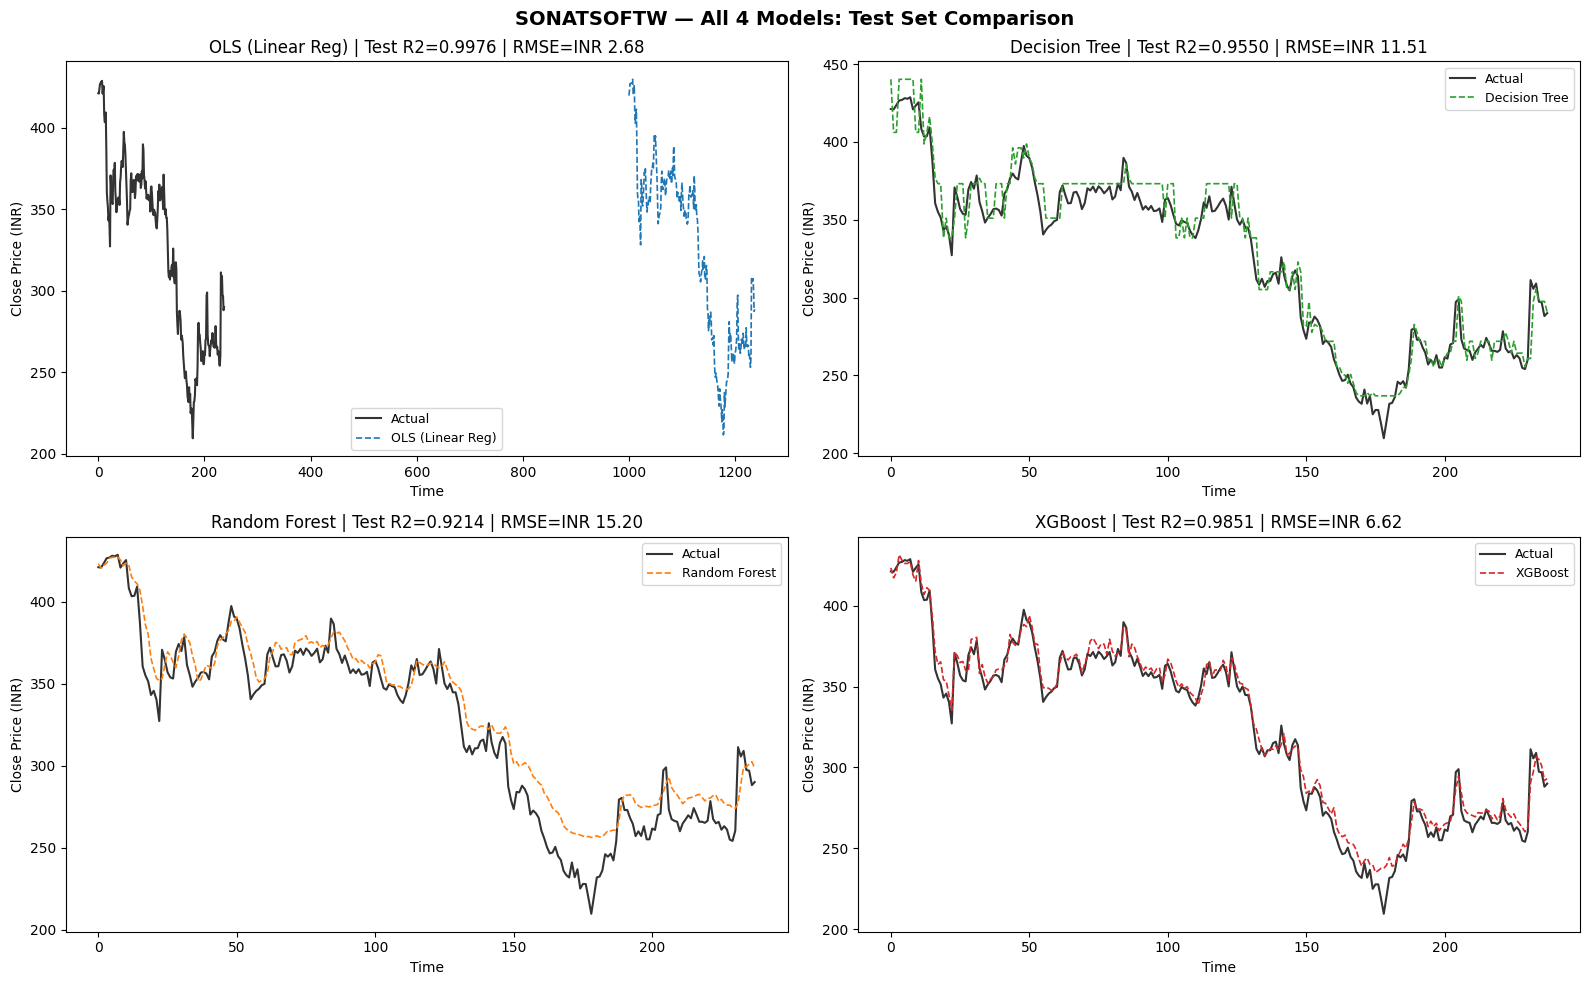

In [67]:
# 2x2 grid — all 4 models predicting on test set
# dashed line close to solid line = good model
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
model_results = [
    ('OLS (Linear Reg)', y_pred_test_ols, ols_test_r2, ols_test_rmse, '#1f77b4'),
    ('Decision Tree',    y_pred_test_dt,  dt_test_r2,  dt_test_rmse,  '#2ca02c'),
    ('Random Forest',    y_pred_test_rf,  rf_test_r2,  rf_test_rmse,  '#ff7f0e'),
    ('XGBoost',          y_pred_test_xgb, xgb_test_r2, xgb_test_rmse, '#d62728'),
]
for ax, (name, pred, r2, rmse, color) in zip(axes.flat, model_results):
    ax.plot(y_test.values, color='black', linewidth=1.5, label='Actual', alpha=0.8)
    ax.plot(pred, color=color, linewidth=1.2, linestyle='--', label=name)
    ax.set_title(f'{name} | Test R2={r2:.4f} | RMSE=INR {rmse:.2f}')
    ax.legend(fontsize=9); ax.set_xlabel('Time'); ax.set_ylabel('Close Price (INR)')
plt.suptitle('SONATSOFTW — All 4 Models: Test Set Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()